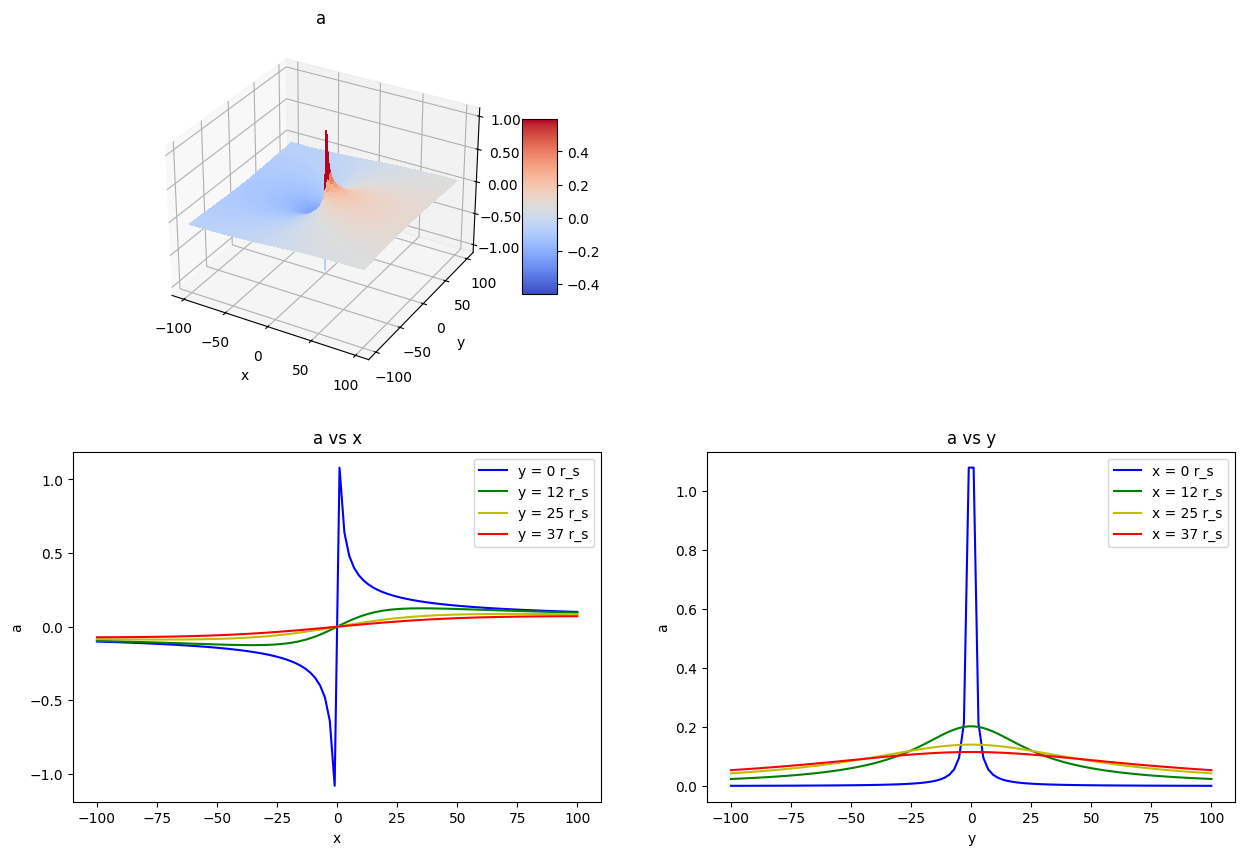

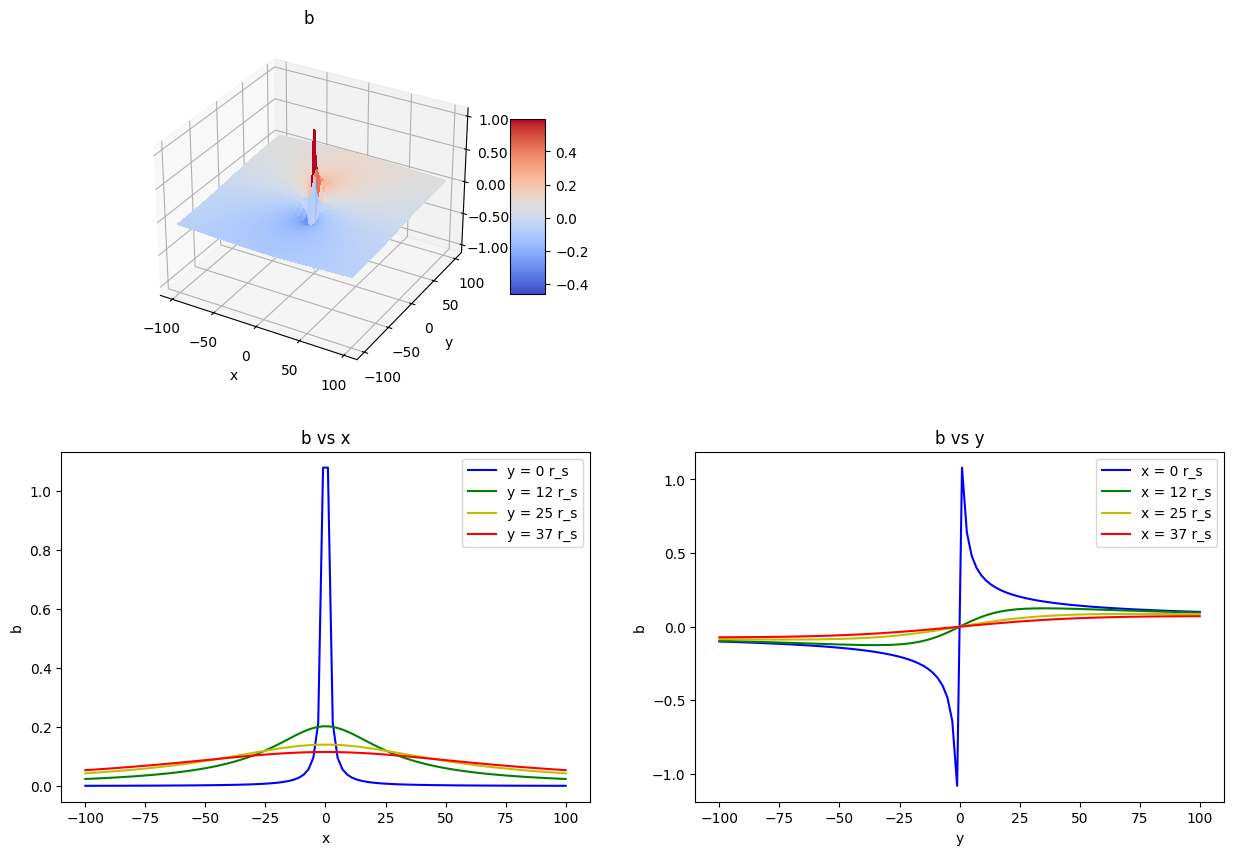

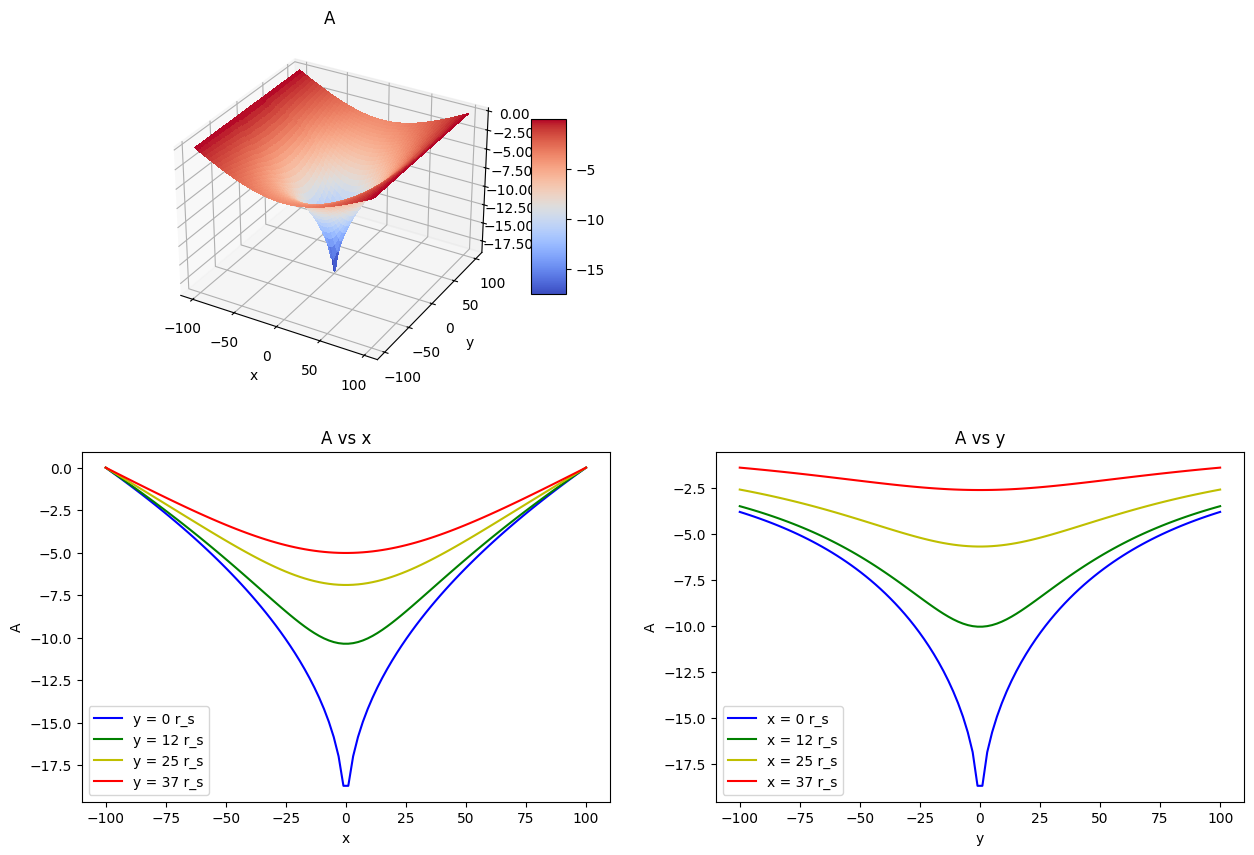

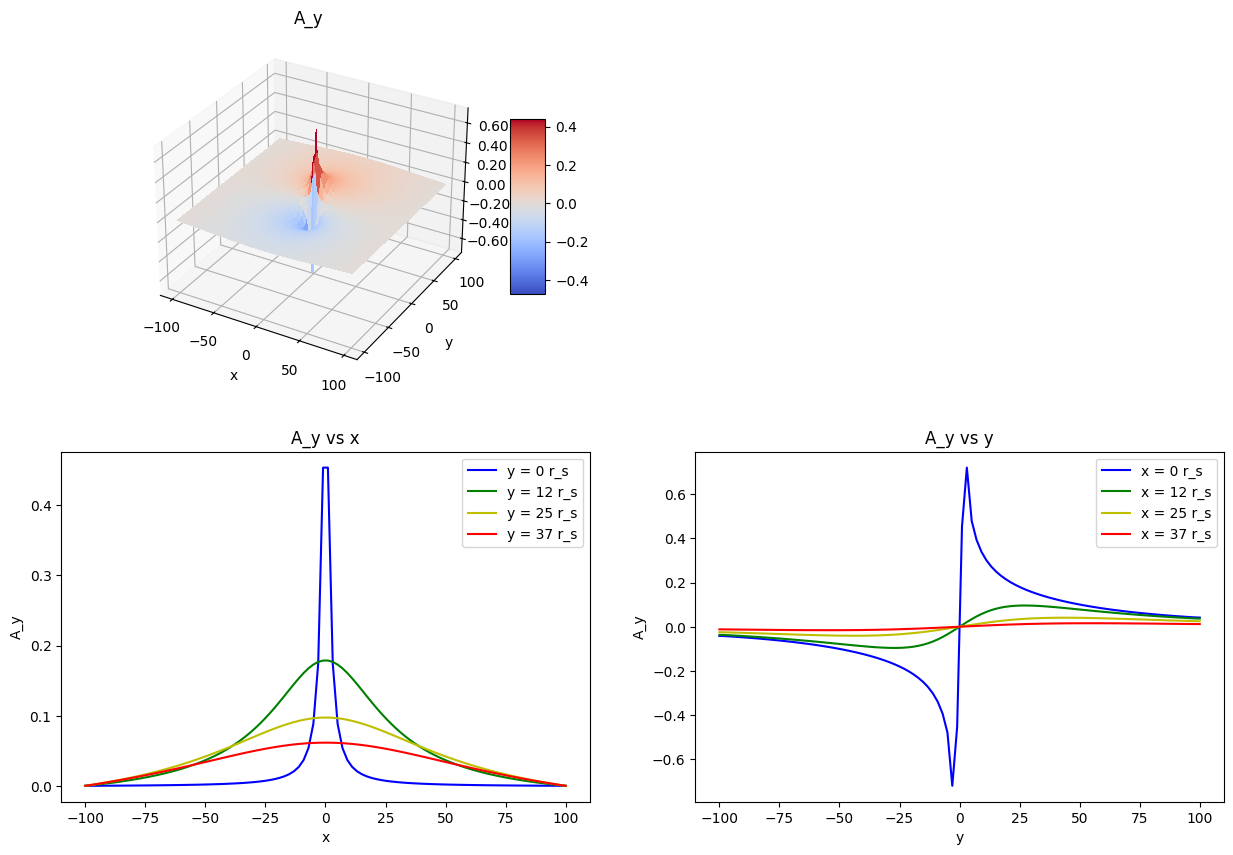

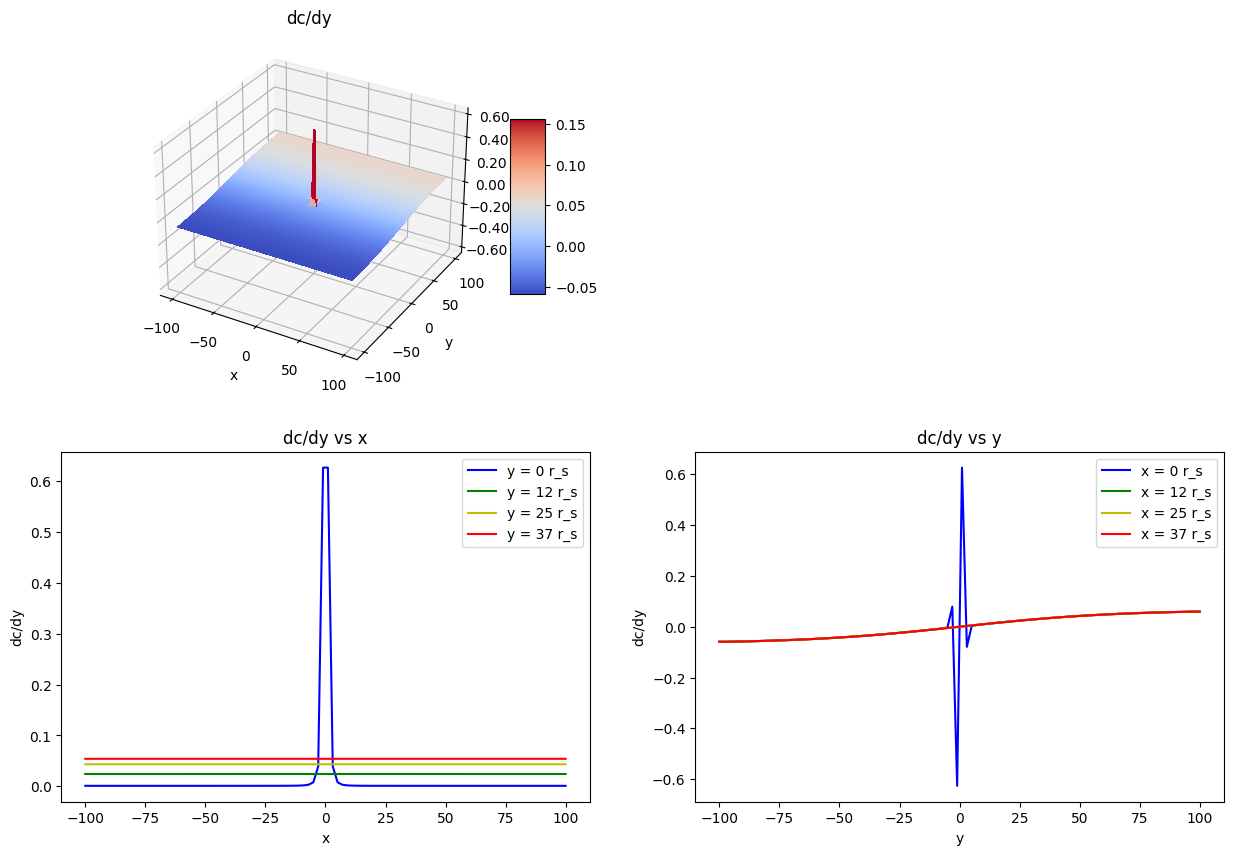

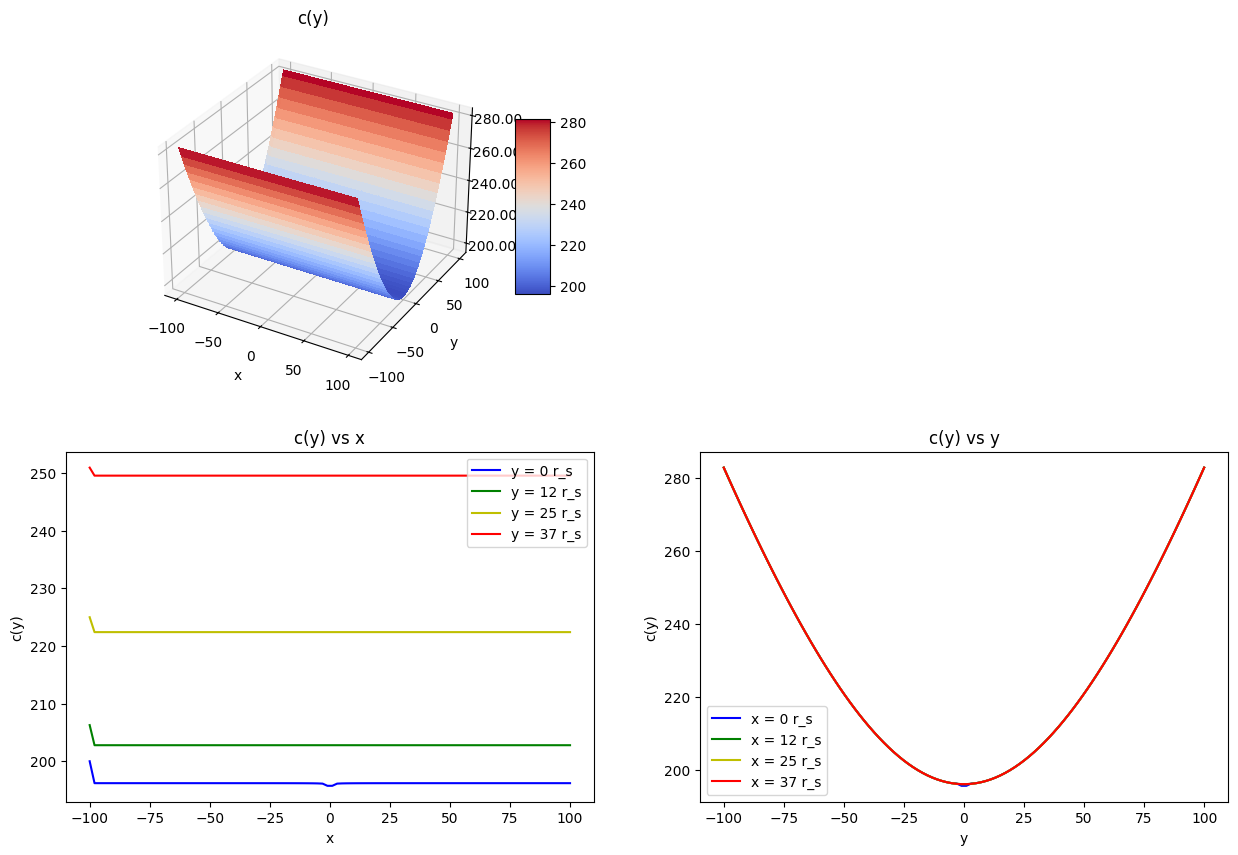

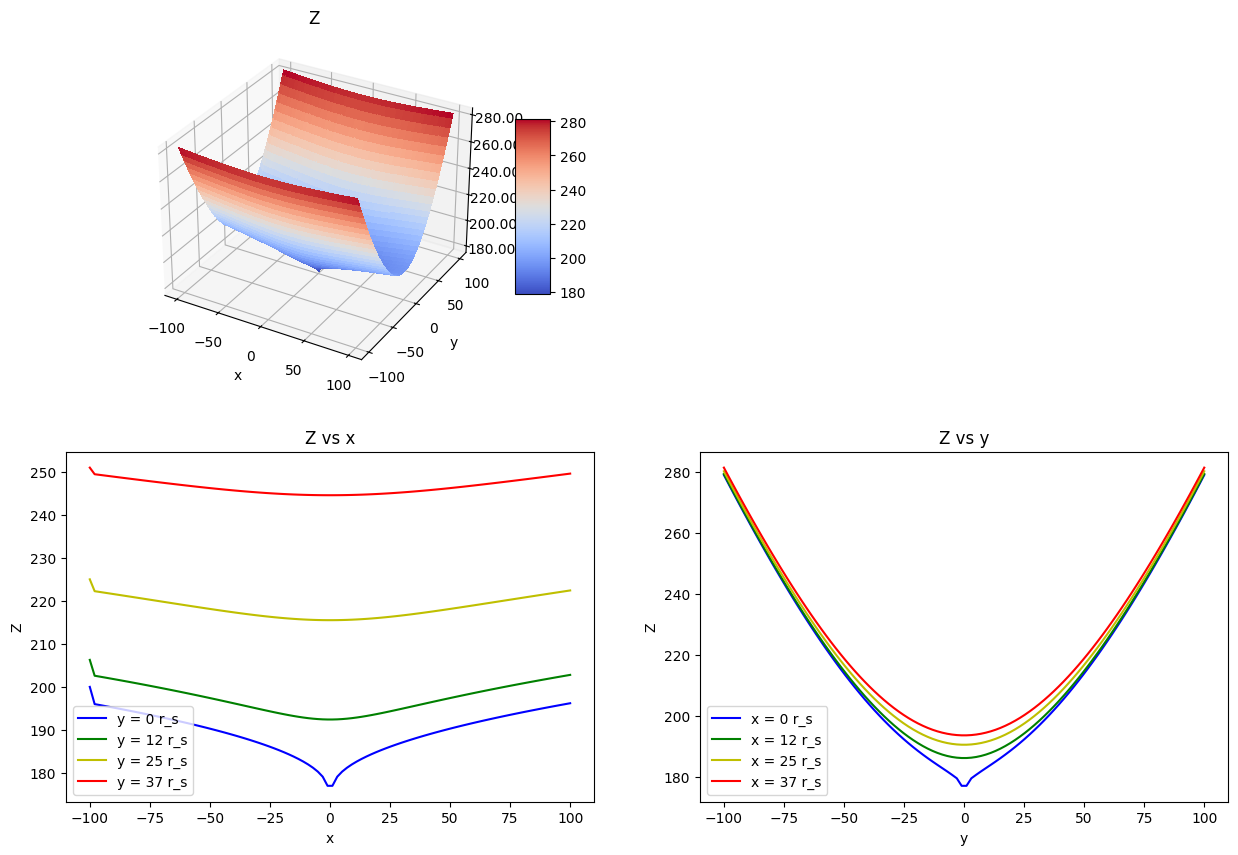

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import trapezoid

# metric

## Schwarzchild
def g_xx(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + ((rs * x**2) / (r**2 * (r - rs)))
def g_yy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + ((rs * y**2) / (r**2 * (r - rs)))
def g_xy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + ((rs * x*y) / (r**2 * (r - rs)))

'''
## Morris_Thorne Wormhole
def b_r(r):
    return 0.5
def g_xx(x, y):
    r = np.sqrt(x**2 + y**2)
    rb = b_r(r)
    return 1 + (x**2 * rb) / (r**2 * (r - rb))
def g_yy(x, y):
    r = np.sqrt(x**2 + y**2)
    rb = b_r(r)
    return 1 + (y**2 * rb) / (r**2 * (r - rb))
'''

# embedding pde's
def partial_x_Z(x, y):
    return np.sign(x) * np.sqrt(g_xx(x, y) - 1)
def partial_y_Z(x, y):
    return np.sign(y) * np.sqrt(g_yy(x, y) - 1)

# constants (change if need)
rs = 1
x_start, x_end = -100*rs, 100*rs
y_start, y_end = -100*rs, 100*rs
n_steps = 100
# more constants
delta_x, delta_y = (x_end - x_start) / (n_steps-1), (y_end - y_start) / (n_steps-1)

# coordinates
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)
R = np.sqrt(x_meshed**2 + y_meshed**2)

## creating a 2d np array to copy later on
grid = np.zeros((y_axis.size, x_axis.size))

## calculating a(x,y) and b(x,y)
a = np.where(R<=1.1*rs, 0, partial_x_Z(x_meshed, y_meshed))
b = np.where(R<=1.1*rs, 0, partial_y_Z(x_meshed, y_meshed))


# calculating A: cumulative integral
A = cumulative_trapezoid(a, x=x_axis, axis=1, initial=0)


# calculating partial A
partial_y_A = grid.copy()

partial_y_A[1:-1,:] = (A[2:,:] - A[:-2,:]) / (2*delta_y)

partial_y_A[0,:] = (A[1,:] - A[0,:]) / delta_y

partial_y_A[-1,:] = (A[-1,:] - A[-2,:]) / delta_y


# calculating d/dy[c(y)]
dc_dy = b - partial_y_A


# calculating c(y): cumulative integral
boundary_condition = 2*np.sqrt(R[:,0:1]**2 - 1)
c_grid = np.copy(grid)
c_grid[:,0:1] = boundary_condition

c_grid[:,1:] = np.where(R[:,1:]<=1.1*rs, 0, c_grid[:,0:1] + cumulative_trapezoid(dc_dy, x=y_axis, axis=0, initial=0)[:,1:])


# evaluating Z
Z = A + c_grid




# plotting
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(15, 10))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)} r_s')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)} r_s')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
## a
plot_3d_and_slice(a, 'a')
## b
plot_3d_and_slice(b, 'b')
## A
plot_3d_and_slice(A, 'A')
## partial_y_A
plot_3d_and_slice(partial_y_A, 'A_y')
## dc_dy
plot_3d_and_slice(dc_dy, 'dc/dy')
## c(y)
plot_3d_and_slice(c_grid, 'c(y)')
## Z
plot_3d_and_slice(Z, 'Z')